# 独立完成"盘尾花数据集”的首次实操(读取一统计-可视化) 

## 1. 实验环境  
平台: Anaconda  
工具: Jupyter Notebook  
语言: Python 3.7  
核心库: Pandas (用于数据处理), NumPy (用于数值计算), Matplotlib 和 Seaborn (用于数据可视化)


# 2. 实验步骤与分析
## 2.1.1 读取数据与查看基础信息
   首先，我们使用 Pandas 库的 read_csv () 函数读取了 iris.csv 文件，并将其成功加载到名为 df 的 DataFrame 变量中。为了了解该数据集的整体情况，我们调用了 df.info() 方法进行查看。  
从 info () 方法的输出结果可知，这份 iris 数据集共包含 150 行数据和 5 列信息。其中，sepal_length、sepal_width、petal_length、petal_width 这 4 列的数据类型为 float64（浮点型，即数字型），而 species 列的数据类型为 object（对象型，即文本型）。值得注意的是，所有列的 “Non-Null Count”（非空值计数）均为 150，这表明该数据集在初始读取时数据完整，不存在缺失值。  


In [13]:
import seaborn as sns
import pandas as pd
import numpy as np
df_iris = sns.load_dataset('iris')
df_iris.to_csv('iris.csv', index=False)
print("'iris.csv' 文件已成功创建在 E:\\ 目录下！")
df = pd.read_csv("iris.csv")
print(df.shape)
print(df.head())
print("数据基础信息 (类型和缺失值)")
df.info()
print("\n数据的形状(行, 列)")
print(df.shape)

'iris.csv' 文件已成功创建在 E:\ 目录下！
(150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
数据基础信息 (类型和缺失值)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

数据的形状(行, 列)
(150, 5)


## 2.1.2 统计样本数量
我们针对数据集中的 species（品种）列调用了 .value_counts() 方法，以统计不同品种的样本数量。统计结果显示，'setosa'、'versicolor'、
'virginica'这三个品种的样本数量各为 50 个。这一结果表明，该数据集是一个类别均衡的数据集，每个类别的样本量完全相同。这种均衡性对于后续的数据分析（如特征对比）和模型训练（如分类模型的性能评估）十分有利，能减少因类别不平衡导致的分析偏差或模型预测倾斜问题。


In [14]:
print("\n每个品种的样本数量")
species_counts = df['species'].value_counts()
print(species_counts)



每个品种的样本数量
setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64


## 2.2.1 手动添加缺失值 (模拟数据污染)
为了模拟数据中可能存在的缺失情况，我们借助 numpy 库的 np.nan 来手动制造缺失值。具体操作中，通过.loc 定位器精确选中索引为 10、11、12、13、14 的共 5 行数据，并将这些行中 petal_width（花瓣宽度）列的值设置为 NaN（缺失值）。  
随后，我们再次调用df.info() 方法进行验证，结果显示 petal_width 列的 “Non-Null Count”（非空值计数）变为 145。结合原始数据该列 150 个非空值的情况，可知 5 个缺失值已成功添加，操作达到了预期效果。

In [15]:
import numpy as np  
df.loc[10:14, 'petal_width'] = np.nan
print("添加缺失值后的数据信息")
df.info()
print("\n 查看具体哪几行发生改变")
print(df.iloc[9:16])

添加缺失值后的数据信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   145 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

 查看具体哪几行发生改变
    sepal_length  sepal_width  petal_length  petal_width species
9            4.9          3.1           1.5          0.1  setosa
10           5.4          3.7           1.5          NaN  setosa
11           4.8          3.4           1.6          NaN  setosa
12           4.8          3.0           1.4          NaN  setosa
13           4.3          3.0           1.1          NaN  setosa
14           5.8          4.0           1.2          NaN  setosa
15           5.7          4.4           1.5          0.4  seto

## 2.2.2 用“中位数”填充缺失值
在处理数据缺失时，均值和中位数是两种常用的填充参考值，但二者特性存在明显差异：均值是所有数值的总和除以数量，对极端值十分敏感；而中位数是排序后位于中间的数值，不受极端值影响，更为稳健，因此在数据清洗中，用中位数填充往往更安全，能避免异常值扭曲数据分布。  
针对 petal_width 列的缺失值，我们先计算了该列在忽略 NaN 值后的中位数，得到 median_value 为 1.3。随后，使用 df ['petal_width'].fillna (median_value, inplace=True) 方法进行填充，其中 inplace=True 参数确保直接在原数据 df 上完成修改。  
填充完成后，再次调用df.info() 验证，结果显示 petal_width 列的 “Non-Null Count” 已恢复为 150，表明所有缺失值均已成功修复，数据完整性得以恢复。

In [16]:
mean_value = df['petal_width'].mean()
print(f"花瓣宽度的均值: {mean_value}")
median_value = df['petal_width'].median()
print(f"花瓣宽度的中位数: {median_value}")
df['petal_width'].fillna(median_value, inplace=True)
print("\n填充后的数据信息")
df.info()
print("\n再次查看第 9 到 15 行")
print(df.iloc[9:16])

花瓣宽度的均值: 1.2351724137931035
花瓣宽度的中位数: 1.3

填充后的数据信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

再次查看第 9 到 15 行
    sepal_length  sepal_width  petal_length  petal_width species
9            4.9          3.1           1.5          0.1  setosa
10           5.4          3.7           1.5          1.3  setosa
11           4.8          3.4           1.6          1.3  setosa
12           4.8          3.0           1.4          1.3  setosa
13           4.3          3.0           1.1          1.3  setosa
14           5.8          4.0           1.2          1.3  setosa
15           5.7    

## 3.3.1 & 3.3.2 新增“花萼面积”与“花瓣面积”
我们利用 Pandas 的向量化运算能力，基于数据集中已有的特征列创建了两个新的衍生列。具体而言，通过将花萼长度（sepal_length）与花萼宽度（sepal_width）相乘，得到了花萼面积列（sepal_area）；将花瓣长度（petal_length）与花瓣宽度（petal_width）相乘，得到了花瓣面积列（petal_area），对应的代码分别为 df ['sepal_area'] = df ['sepal_length'] * df ['sepal_width'] 和 df ['petal_area'] = df ['petal_length'] * df ['petal_width']。  
为验证新列是否成功添加，我们调用 df.head () 查看数据的前 5 行，结果显示 sepal_area 和 petal_area 两个新列已出现在数据表的末尾，表明操作顺利完成。

In [17]:
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
df['petal_area'] = df['petal_length'] * df['petal_width']
print("查看新增面积列后的数据")
print(df.head())

查看新增面积列后的数据
   sepal_length  sepal_width  petal_length  petal_width species  sepal_area  \
0           5.1          3.5           1.4          0.2  setosa       17.85   
1           4.9          3.0           1.4          0.2  setosa       14.70   
2           4.7          3.2           1.3          0.2  setosa       15.04   
3           4.6          3.1           1.5          0.2  setosa       14.26   
4           5.0          3.6           1.4          0.2  setosa       18.00   

   petal_area  
0        0.28  
1        0.28  
2        0.26  
3        0.30  
4        0.28  


## 2.3.3计算特征间的相关性矩阵
我们调用了 df.corr () 方法，该方法会自动计算数据集中所有数值型列（共 6 列）两两之间的皮尔逊相关系数。  
操作后生成了一个 6x6 的相关性矩阵，矩阵中的数值范围在 - 1 到 1 之间：其中 1 表示两列数据完全正相关，-1 表示完全负相关，0 则表示两者无相关关系。这份相关性矩阵将作为下一步绘制热力图的基础数据，为后续的相关性可视化分析提供支持。


In [18]:
correlation_matrix = df.corr()
print("--- 特征相关性矩阵 ---")
print(correlation_matrix)

--- 特征相关性矩阵 ---
              sepal_length  sepal_width  petal_length  petal_width  \
sepal_length      1.000000    -0.117570      0.871754     0.793019   
sepal_width      -0.117570     1.000000     -0.428440    -0.337107   
petal_length      0.871754    -0.428440      1.000000     0.924878   
petal_width       0.793019    -0.337107      0.924878     1.000000   
sepal_area        0.679180     0.643461      0.360909     0.372184   
petal_area        0.855937    -0.282685      0.954383     0.963970   

              sepal_area  petal_area  
sepal_length    0.679180    0.855937  
sepal_width     0.643461   -0.282685  
petal_length    0.360909    0.954383  
petal_width     0.372184    0.963970  
sepal_area      1.000000    0.457881  
petal_area      0.457881    1.000000  


## 2.4.1 绘制“花瓣面积”的箱线图 (按品种分组)
我们使用 Seaborn 库的 sns.boxplot (x='species', y='petal_area', data=df) 函数，绘制了不同品种与花瓣面积的箱线图。  
该箱线图直观呈现了三个鸢尾品种在 “花瓣面积” 特征上的分布差异：'setosa'（山鸢尾）的花瓣面积显著小于另外两个品种，且数据分布极为集中（箱体很短）；'versicolor'（变色鸢尾）的花瓣面积处于中间水平；'virginica'（维吉尼亚鸢尾）的花瓣面积最大。三个品种在花瓣面积上的数据区间几乎没有重叠，这表明 “花瓣面积” 是一个区分度非常高的特征，能有效帮助区分不同品种的鸢尾花。

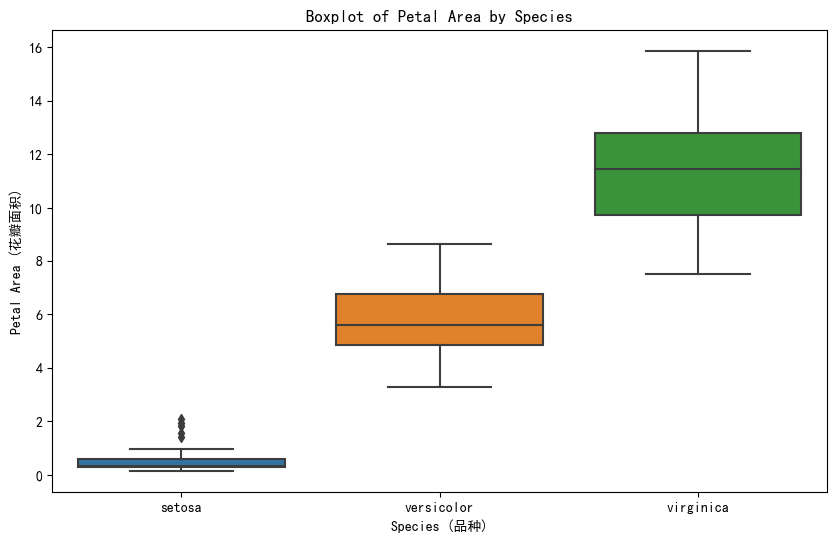

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False   
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal_area', data=df)
plt.title('Boxplot of Petal Area by Species') 
plt.xlabel('Species (品种)')                  
plt.ylabel('Petal Area (花瓣面积)')           
plt.show()

## 2.4.2 绘制“花萼面积 vs 花瓣面积”的散点图
我们使用 Seaborn 库的 sns.scatterplot () 函数，以花萼面积（sepal_area）为 x 轴、花瓣面积（petal_area）为 y 轴绘制散点图，并通过 hue='species' 参数让散点根据鸢尾花品种自动着色，同时生成对应图例。为了更清晰地观察数据分布，还调用 plt.grid (True) 为图表添加了网格。  
从散点图结果来看，它清晰展示了两个面积特征之间的关系及不同品种的分布差异：'setosa'（山鸢尾）品种的散点（蓝色）集中在图的左下角区域，因花瓣面积显著较小，与另外两个品种形成明显分离；'versicolor'（变色鸢尾）和 'virginica'（维吉尼亚鸢尾）的散点在花萼面积维度存在一定重叠，但在花瓣面积维度仍有较好的区分度。整体观察，花萼面积与花瓣面积呈现出一定的正相关趋势，数据点大致沿左下到右上的方向分布。

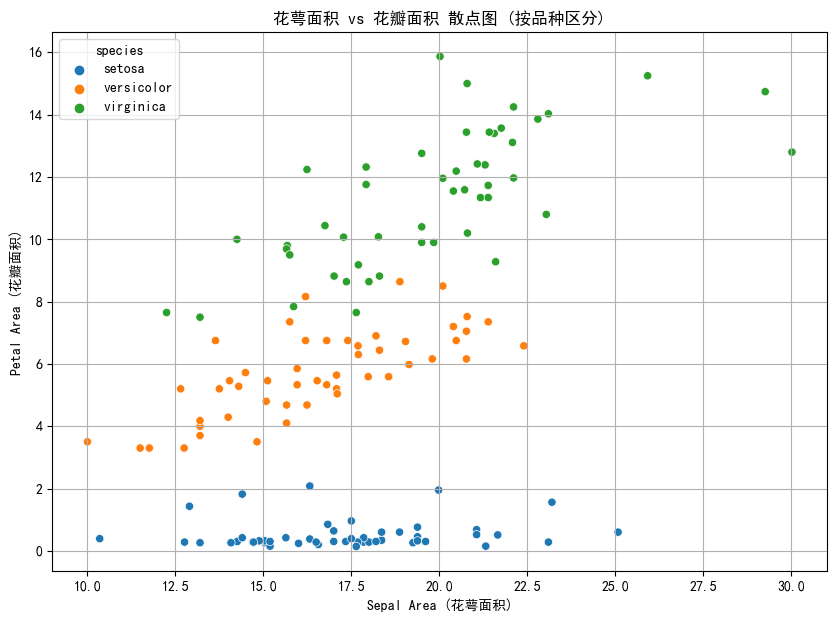

In [20]:
plt.figure(figsize=(10, 7))  
sns.scatterplot(x='sepal_area', y='petal_area', hue='species', data=df)
plt.grid(True)
plt.title('花萼面积 vs 花瓣面积 散点图 (按品种区分)')
plt.xlabel('Sepal Area (花萼面积)')
plt.ylabel('Petal Area (花瓣面积)')
plt.show()

## 4.3. 绘制特征相关性热力图
我们使用 Matplotlib 的 plt.imshow () 函数，将此前计算得到的相关性矩阵（correlation_matrix）传入，绘制出热力图。为了让图表信息更完整，我们调用 plt.colorbar () 添加了颜色条图例，用于直观对应颜色与相关系数的关系；同时通过 plt.xticks 和 plt.yticks 设置了坐标轴标签，使其清晰显示数据集中的 6 个特征名称。  
热力图的核心作用是将抽象的相关系数数值转化为直观的颜色深浅：图中对角线位置（代表一个特征与自身的相关性）颜色最亮，相关系数值均为 1.0，符合完全正相关的定义。在强正相关的亮色区域中，petal_length（花瓣长度）与 petal_area（花瓣面积）的相关性极强，数值接近 1.0，这一结果符合逻辑，因为花瓣面积正是由花瓣长度和宽度相乘计算得出。而在弱相关或负相关的暗色区域，sepal_width（花萼宽度）与 petal_length（花瓣长度）、petal_width（花瓣宽度）均呈现出轻微的负相关关系。  
通过这份热力图可以快速识别特征间的关联模式：既能明确哪些特征高度相关（如花瓣相关的几个特征），也能发现哪些特征相对独立（如 sepal_width 花萼宽度），为后续的特征选择和数据分析提供了清晰的参考依据。

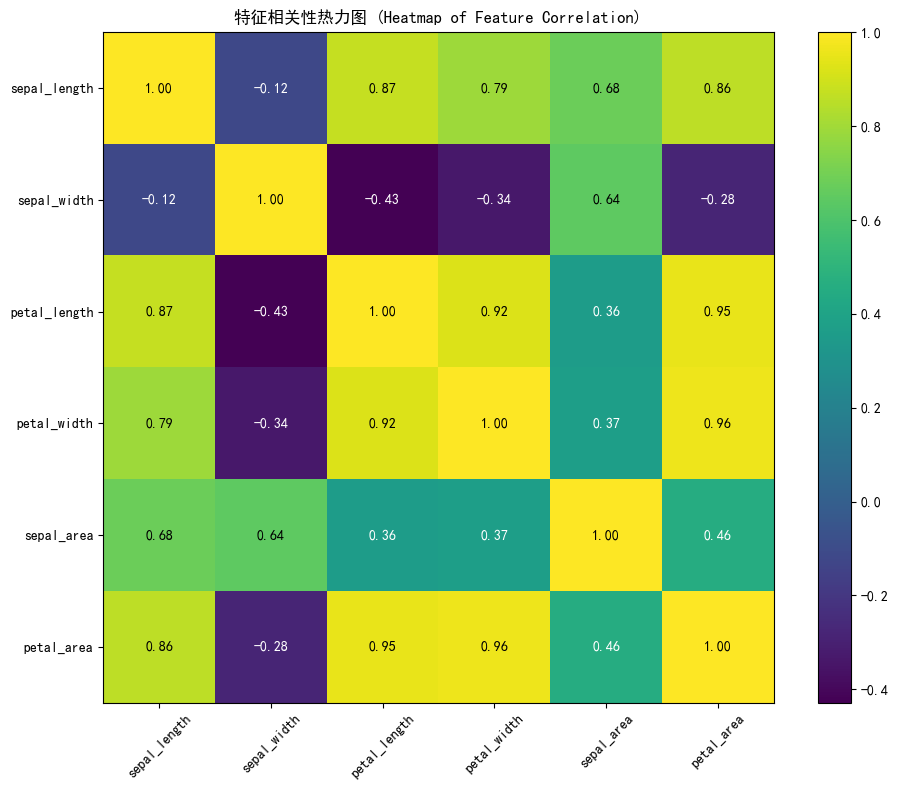

In [21]:

plt.figure(figsize=(10, 8)) 
im = plt.imshow(correlation_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(im)

labels = correlation_matrix.columns
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45) 
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.title('特征相关性热力图 (Heatmap of Feature Correlation)')


for i in range(len(labels)):
    for j in range(len(labels)):
        text = plt.text(j, i, f'{correlation_matrix.loc[labels[i], labels[j]]:.2f}',
                       ha='center', va='center', color='w' if correlation_matrix.loc[labels[i], labels[j]] < 0.6 else 'black') 
plt.tight_layout()
plt.show()

# 实验总结
本次实操完整地演练了数据分析的基本流程：从数据读取、检查、清洗（缺失值处理），到特征工程（创建新特征），再到最后的数据可视化（箱线图、散点图、热力图）。通过这个流程，我们验证了鸢尾花数据集中“花瓣”相关的特征（长度、宽度、面积）对于区分不同品种具有极高的价值。

In [22]:
jupyter nbconvert --to pdf your_notebook.ipynb


SyntaxError: invalid syntax (1738622736.py, line 1)